# Fraud Detection Starter: Market Anomalies (OpenBB + Simple ML)

This notebook is a starter template for detecting suspicious market anomalies
using historical price/volume data.

Goal: Flag time periods that look abnormal using simple features + ML.

This is NOT a production fraud detector.
It is a baseline for community improvements.


In [7]:
# !pip install -U openbb scikit-learn matplotlib pandas numpy
# python -m pip install ipykernel jupyter




In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from openbb import obb


In [9]:
SYMBOL = "AAPL"
START_DATE = "2023-01-01"

data = obb.equity.price.historical(
    symbol=SYMBOL,
    start_date=START_DATE
)

df = data.to_dataframe()
df.head()


,open,high,low,close,volume,dividend
date,,,,,,
2023-01-03,130.279999,130.899994,124.169998,125.070000,112117500,0.0
2023-01-04,126.889999,128.660004,125.080002,126.360001,89113600,0.0
2023-01-05,127.129997,127.769997,124.760002,125.019997,80962700,0.0
2023-01-06,126.010002,130.289993,124.889999,129.619995,87754700,0.0
2023-01-09,130.470001,133.410004,129.889999,130.149994,70790800,0.0


In [10]:
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
else:
    df.index = pd.to_datetime(df.index)

df = df.sort_index()
df.tail()


,open,high,low,close,volume,dividend
date,,,,,,
2026-01-14,259.489990,261.820007,256.709991,259.959991,40019400,0.0
2026-01-15,260.649994,261.040009,257.049988,258.209991,39388600,0.0
2026-01-16,257.899994,258.899994,254.929993,255.529999,72142800,0.0
2026-01-20,252.729996,254.789993,243.419998,246.699997,80267500,0.0
2026-01-21,248.710007,251.559998,245.190002,248.940002,37544572,0.0


In [11]:
feat = pd.DataFrame(index=df.index)

feat["log_ret"] = np.log(df["close"]).diff()
feat["ret_vol_20"] = feat["log_ret"].rolling(20).std()

if "high" in df.columns and "low" in df.columns:
    feat["hl_range"] = (df["high"] - df["low"]) / df["close"]
else:
    feat["hl_range"] = np.nan

if "volume" in df.columns:
    v = df["volume"]
    feat["vol_z_20"] = (v - v.rolling(20).mean()) / v.rolling(20).std()
else:
    feat["vol_z_20"] = np.nan

X = feat.dropna()
X.head()


,log_ret,ret_vol_20,hl_range,vol_z_20
date,,,,
2023-02-01,0.007870,0.012662,0.036375,0.739959
2023-02-02,0.036392,0.014211,0.019958,3.325189
2023-02-03,0.024107,0.013820,0.061812,3.408373
2023-02-06,-0.018091,0.013863,0.015290,-0.210707
2023-02-07,0.019062,0.014051,0.029680,0.347540


In [12]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42
)

model.fit(X)

pred = model.predict(X)
score = model.decision_function(X)

result = df.loc[X.index].copy()
result["is_anomaly"] = pred == -1
result["score"] = score

result[result["is_anomaly"]].head()


,open,high,low,close,volume,dividend,is_anomaly,score
date,,,,,,,,
2024-05-03,186.649994,187.000000,182.660004,183.380005,163224100,0.0,True,-0.009232
2024-06-11,193.649994,207.160004,193.630005,207.149994,172373300,0.0,True,-0.072758
2024-08-05,199.089996,213.500000,196.000000,209.270004,119548600,0.0,True,-0.041136
2025-04-03,205.539993,207.490005,201.250000,203.190002,103419000,0.0,True,-0.031490
2025-04-04,193.889999,199.880005,187.339996,188.380005,125910900,0.0,True,-0.079354


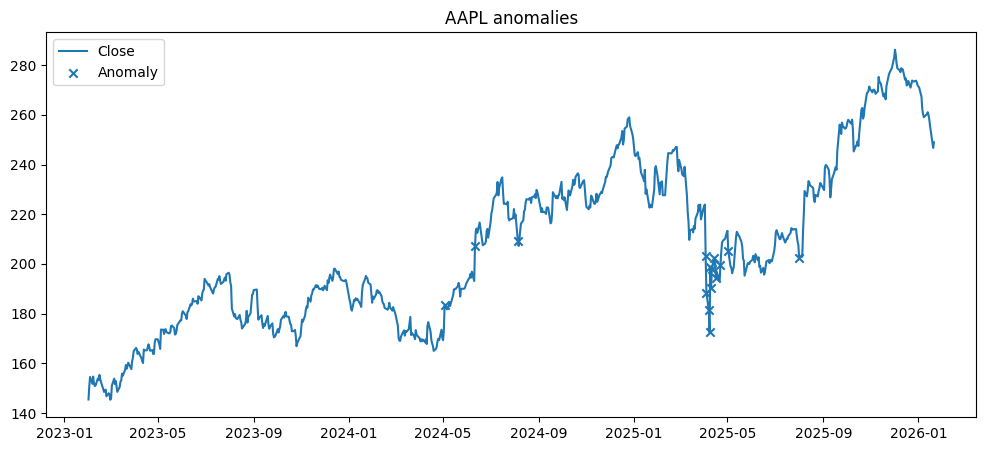

In [13]:
anoms = result[result["is_anomaly"]]

plt.figure(figsize=(12,5))
plt.plot(result.index, result["close"], label="Close")
plt.scatter(anoms.index, anoms["close"], marker="x", label="Anomaly")
plt.title(f"{SYMBOL} anomalies")
plt.legend()
plt.show()


**Interpretation**

Blue X markers highlight periods where the model detected unusual behavior
based on returns, volatility, and volume patterns.

These may correspond to:
- earnings announcements
- macroeconomic news
- abnormal trading activity

Not all anomalies imply fraud.
